# Assignment 2 — Shopper Purchase Intention

BITS Virtual Lab runbook. This notebook trains five classifiers on the UCI Online Shoppers Purchasing Intention dataset and prints the six required metrics on a stratified held-out test split.

Run all cells from the `Assignment2` project folder (or set `PROJECT_ROOT` below).

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "train_models.py").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from train_models import (
    FEATURE_COLUMNS,
    MODEL_SPECS,
    TARGET_COLUMN,
    build_model_pipeline,
    load_session_table,
    probability_for_purchase,
    score_predictions,
)
from sklearn.model_selection import train_test_split

print("Project root:", PROJECT_ROOT)
print("Feature count:", len(FEATURE_COLUMNS))

Project root: /Users/ksharma16/IdeaProjects/MachineLearning/Assignment2
Feature count: 17


In [2]:
sessions = load_session_table()
print("Rows:", len(sessions))
print("Columns:", list(sessions.columns))
print("Purchase rate:\n", sessions[TARGET_COLUMN].value_counts(normalize=True).round(4))
sessions.head()

Rows: 12330
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
Purchase rate:
 Revenue
False    0.8453
True     0.1547
Name: proportion, dtype: float64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    sessions[FEATURE_COLUMNS],
    sessions[TARGET_COLUMN],
    test_size=0.20,
    stratify=sessions[TARGET_COLUMN],
    random_state=42,
)
print("Train sessions:", len(x_train), "| Test sessions:", len(x_test))

Train sessions: 9864 | Test sessions: 2466


In [4]:
metric_rows = {}
fitted = {}
for model_name, (_filename, estimator) in MODEL_SPECS.items():
    pipeline = build_model_pipeline(estimator)
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    y_score = probability_for_purchase(pipeline, x_test)
    metric_rows[model_name] = score_predictions(y_test, y_pred, y_score)
    fitted[model_name] = (pipeline, y_pred)
    print(model_name, metric_rows[model_name])

comparison = pd.DataFrame(metric_rows).T
comparison

Logistic Regression {'Accuracy': 0.8406, 'AUC': 0.8934, 'Precision': 0.4905, 'Recall': 0.7435, 'F1': 0.5911, 'MCC': 0.5138}
Decision Tree {'Accuracy': 0.8362, 'AUC': 0.9231, 'Precision': 0.4836, 'Recall': 0.8482, 'F1': 0.616, 'MCC': 0.5548}


/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ksharma16/IdeaProjects/MachineLearning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid 

kNN {'Accuracy': 0.8731, 'AUC': 0.8177, 'Precision': 0.6927, 'Recall': 0.3246, 'F1': 0.4421, 'MCC': 0.4159}
Naive Bayes {'Accuracy': 0.2729, 'AUC': 0.733, 'Precision': 0.1726, 'Recall': 0.9738, 'F1': 0.2933, 'MCC': 0.1289}
Random Forest (Ensemble) {'Accuracy': 0.8678, 'AUC': 0.9183, 'Precision': 0.5522, 'Recall': 0.7749, 'F1': 0.6449, 'MCC': 0.5787}


,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.8406,0.8934,0.4905,0.7435,0.5911,0.5138
Decision Tree,0.8362,0.9231,0.4836,0.8482,0.6160,0.5548
kNN,0.8731,0.8177,0.6927,0.3246,0.4421,0.4159
Naive Bayes,0.2729,0.7330,0.1726,0.9738,0.2933,0.1289
Random Forest (Ensemble),0.8678,0.9183,0.5522,0.7749,0.6449,0.5787


Highest MCC model: Random Forest (Ensemble)
              precision    recall  f1-score   support

 No purchase       0.96      0.88      0.92      2084
    Purchase       0.55      0.77      0.64       382

    accuracy                           0.87      2466
   macro avg       0.75      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466



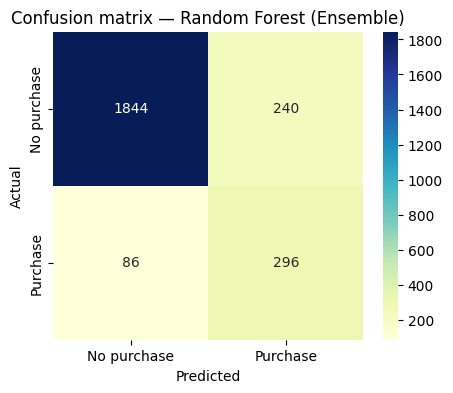

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

winner_name = comparison["MCC"].idxmax()
_, winner_pred = fitted[winner_name]
print("Highest MCC model:", winner_name)
print(classification_report(y_test, winner_pred, target_names=["No purchase", "Purchase"]))

matrix = confusion_matrix(y_test, winner_pred, labels=[False, True])
plt.figure(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No purchase", "Purchase"],
    yticklabels=["No purchase", "Purchase"],
)
plt.title(f"Confusion matrix — {winner_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()